In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import numpy as np
import geopandas as gpd
import pandas as pd
import glob
import os
import shutil
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from scipy.stats import normaltest, probplot, skew, kurtosis

Summarize P1 layers

In [ ]:
# Folder containing the CSV files
data_dir = '/content/drive/MyDrive/CCRI/ccri_repo/data'

#!cp -r /content/drive/MyDrive/p1_exposure/* /content/drive/MyDrive/CCRI/ccri_repo/data/p1_exposure/
!find /content/drive/MyDrive/p1_exposure/ -type f \
  ! -name '*ge*' \
  ! -name '*topic*' \
  -exec cp {} /content/drive/MyDrive/CCRI/ccri_repo/data/p1_exposure/ \;



In [ ]:
adm0_df = gpd.read_file('/content/drive/MyDrive/CCRI/boundary/final_georepo/adm0.geojson')

In [ ]:
adm0_df.columns

Index(['ucode', 'uuid', 'concept_uuid', 'is_latest', 'start_date', 'end_date',
       'name', 'level', 'level_name', 'type', 'PCode', 'ISO3', 'UcodeIn',
       'WFP_ID', 'MapClr', 'UcodeID', 'default', 'name_en', 'Map label',
       'Alt name', 'Alternative name', 'geometry'],
      dtype='object')

In [ ]:
adm0_df = adm0_df[['ucode', 'type', 'name']]

In [ ]:
path = f'{data_dir}/p1_exposure'
all_files = glob.glob(path + "/*.csv")

for file in all_files:
    # Exclude the specified file
    df = pd.read_csv(file, index_col=None, header=0)
    df = df.rename(columns={'exposed': 'child_population_exposed'})

    #chose 'state' only
    df = df.merge(adm0_df, left_on='ucode', right_on='ucode')
    df =  df[(df['type'] == 'State')]
    filename_only = file.split('/')[-1]
    first_two_words = '_'.join(filename_only.split('_')[:2])
    print(f"{first_two_words}: {df['child_population_exposed'].sum()}")

river_flood: 350357643.5383611
coastal_flood: 35602623.914726675
tropical_storm: 663349661.233389
agricultural_drought: 1355250790.723874
drought_spei: 1420172794.092682
drought_spi: 1199596049.7743726
heatwave_frequency: 1275660186.1619039
heatwave_duration: 1137921873.5759063
heatwave_severity: 299423194.8584231
extreme_heat: 1183160071.8471837
fire_FRP: 87928661.19582996
fire_frequency: 142090200.47533512
sand_dust: 130289284.84160529
air_pollution: 2307211161.439795
vectorborne_malariapv: 626255696.3425612
vectorborne_malariapf: 704450033.0967402


Hazard data normalization test with plots

In [ ]:
#define function to remove outliers and find min max values to reduce skew
def trim_outliers_iteratively(values, max_skew=2, max_kurtosis=3.5):
    """
    Iteratively removes extreme min/max values until skewness <= 2 and kurtosis <= 3.5.
    Returns the trimmed dataset along with the final min and max.
    """
    # values = values.dropna().values  # Ensure no NaNs
    # values = np.log1p(values)
    while True:
        current_skew = skew(values)
        current_kurtosis = kurtosis(values)

        if abs(current_skew) <= max_skew and current_kurtosis <= max_kurtosis:
            break  # Stop if conditions are met

        # Remove min and max values
        min_val, max_val = values.min(), values.max()
        values = values[(values > min_val) & (values < max_val)]  # Trim extreme min/max

    return values, values.min(), values.max()

In [ ]:
def boxplot_outlier_detection(values):
    """
    Detect outliers using the IQR method (1.5 IQR rule).
    """
    # Calculate Q1 (25th percentile) and Q3 (75th percentile)
    Q1 = np.percentile(values, 25)
    Q3 = np.percentile(values, 75)
    # Calculate IQR (Interquartile Range)
    IQR = Q3 - Q1
    # Define lower and upper bounds for outliers
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    # Return values that are within bounds
    return values[(values >= lower_bound) & (values <= upper_bound)], lower_bound, upper_bound

ploting normalized absolute exposure

In [ ]:
iso3_name = 'iso3'
adm_name = 'adm0_name'

processed : river_flood min: 0.1 max: 7.876261348942618
river_flood: Log Transformation and Scaling - skew=-1.080, kurtosis=0.011
IQR processed : river_flood min: 1.4780013287148184 max: 8.279791978841086


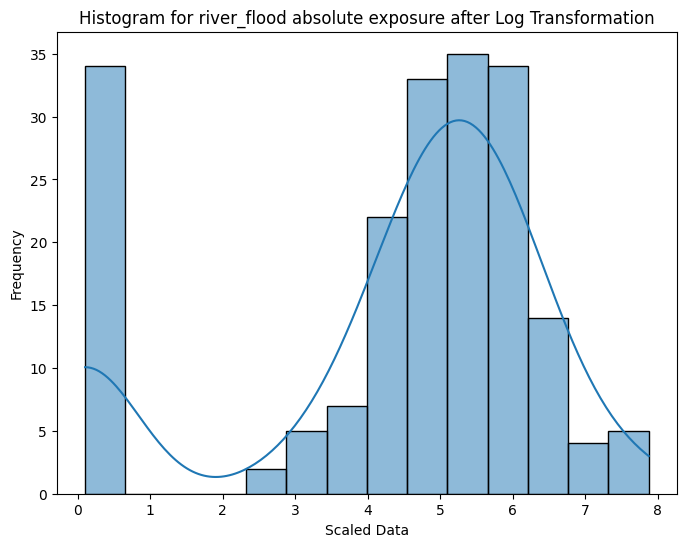

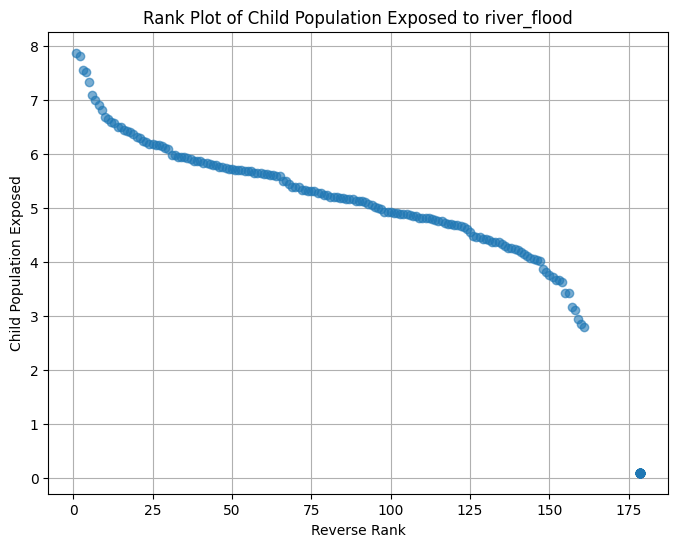

processed : coastal_flood min: 0.1 max: 7.163006569250576
coastal_flood: Log Transformation and Scaling - skew=-0.196, kurtosis=-1.272
IQR processed : coastal_flood min: -6.095972878855347 max: 10.426621464758911


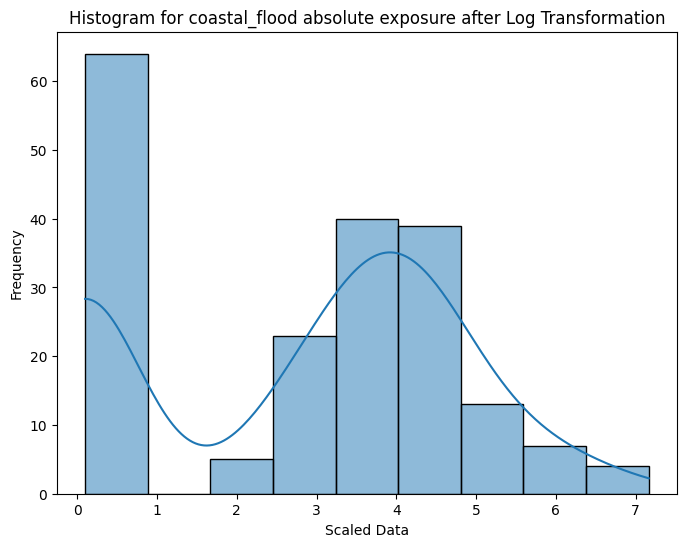

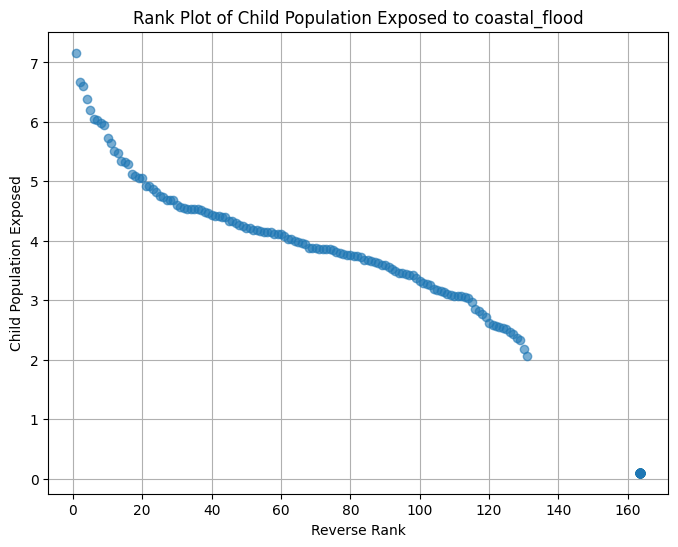

processed : tropical_storm min: 0.1 max: 8.194577209993167
tropical_storm: Log Transformation and Scaling - skew=0.613, kurtosis=-1.423
IQR processed : tropical_storm min: -8.069919396915251 max: 13.716532328192084


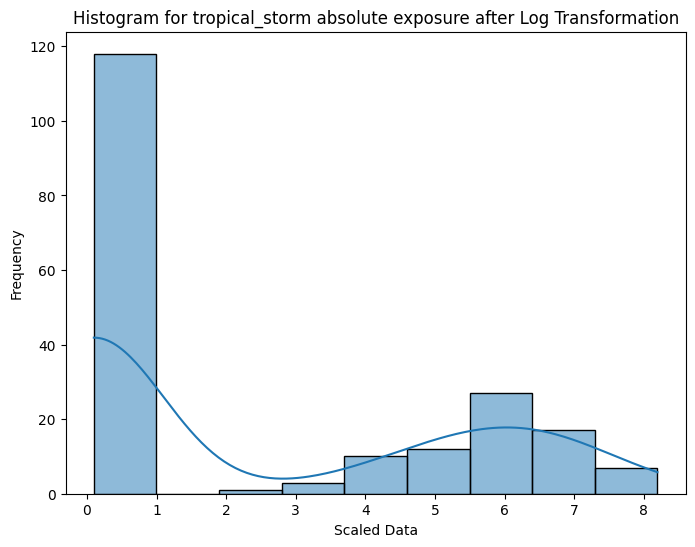

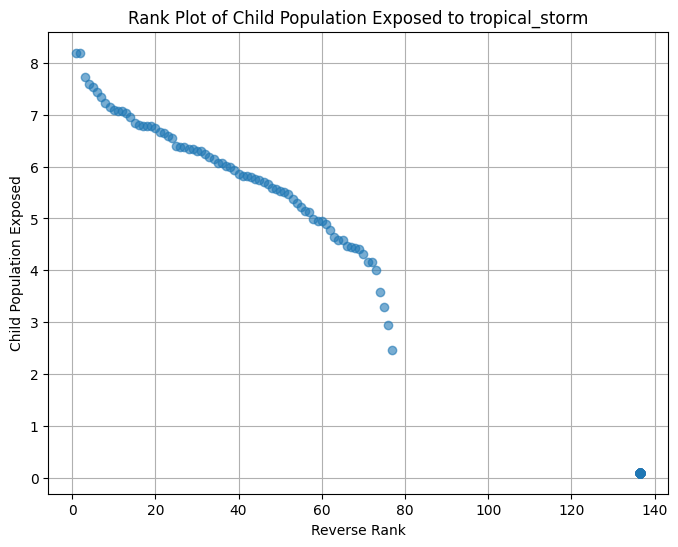

processed : agricultural_drought min: 0.1 max: 8.570492149357596
agricultural_drought: Log Transformation and Scaling - skew=-1.547, kurtosis=1.434
IQR processed : agricultural_drought min: 2.384290265801422 max: 9.2111122378878


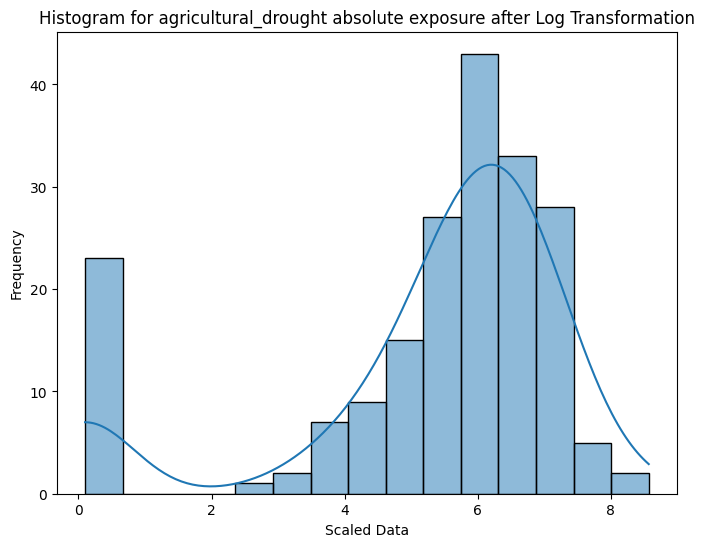

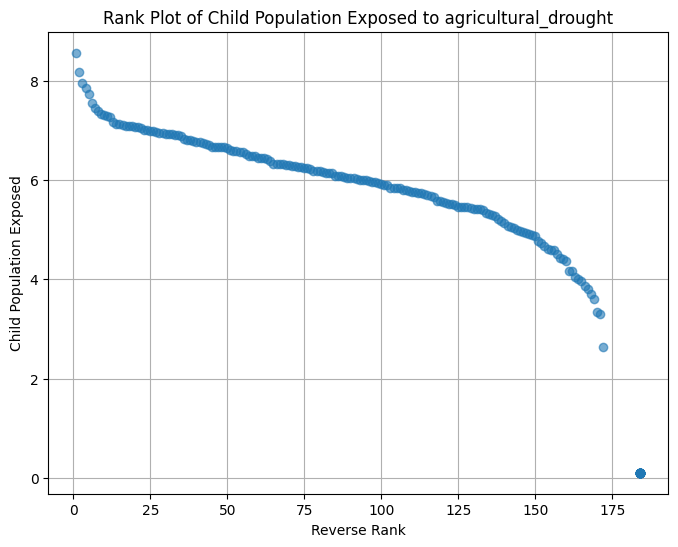

processed : drought_spei min: 0.1 max: 8.358899686680653
drought_spei: Log Transformation and Scaling - skew=-1.688, kurtosis=1.934
IQR processed : drought_spei min: 2.8073359055291416 max: 9.214788738967505


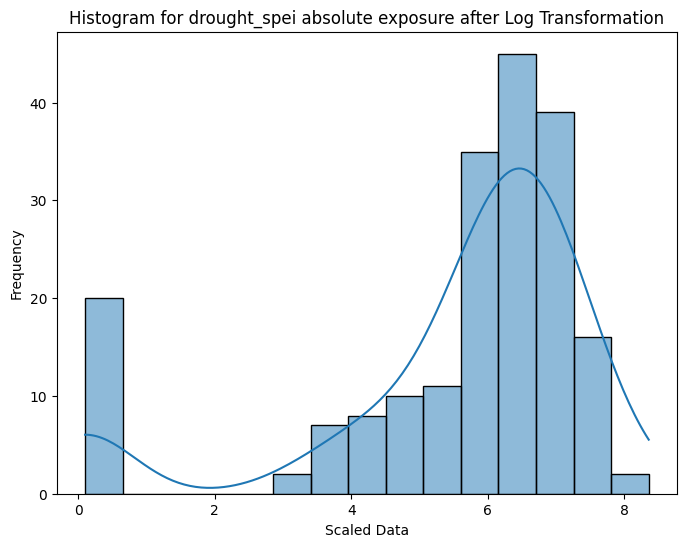

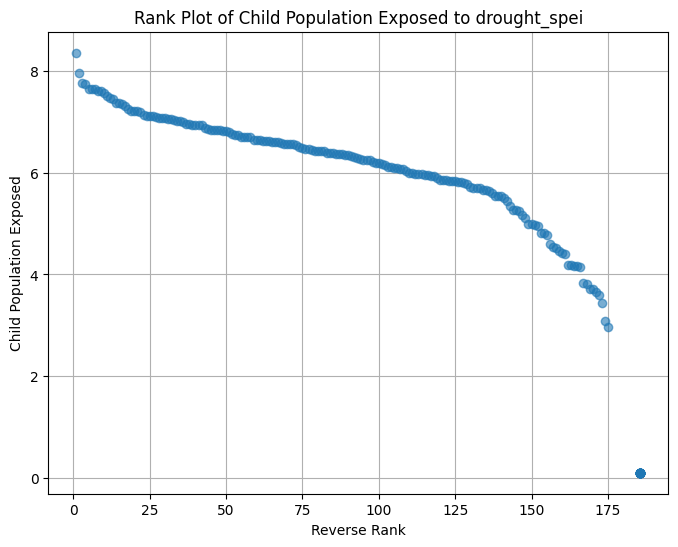

processed : drought_spi min: 0.1 max: 8.324781820537787
drought_spi: Log Transformation and Scaling - skew=-1.207, kurtosis=0.104
IQR processed : drought_spi min: 0.9926672292306606 max: 10.041404873230542


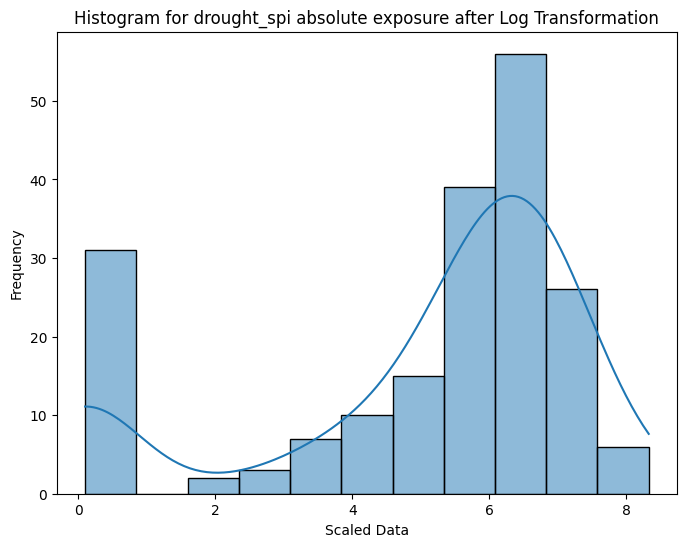

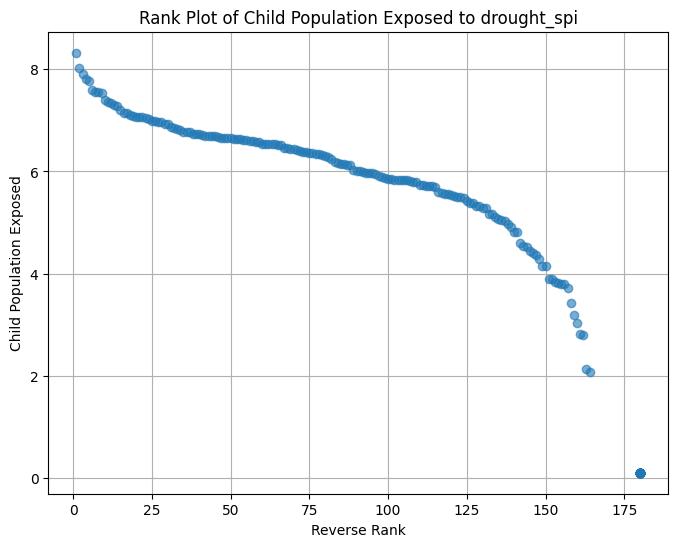

processed : heatwave_frequency min: 0.1 max: 8.048537927860341
heatwave_frequency: Log Transformation and Scaling - skew=-1.352, kurtosis=3.413
IQR processed : heatwave_frequency min: 3.4939652320835513 max: 8.847434074045703


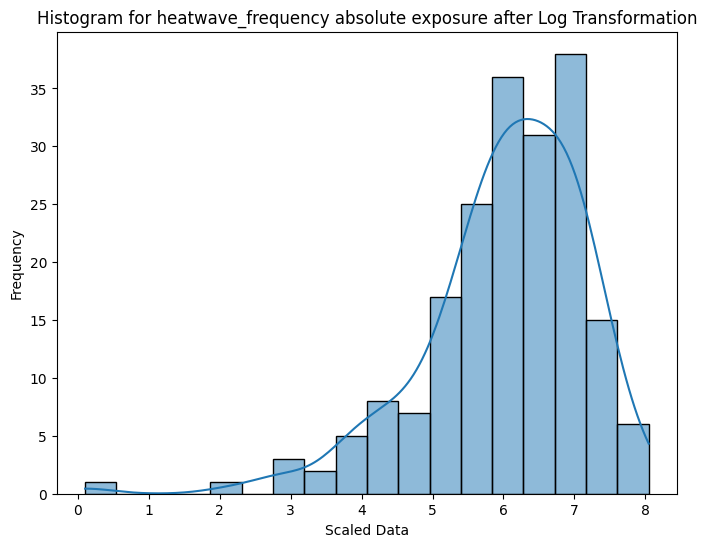

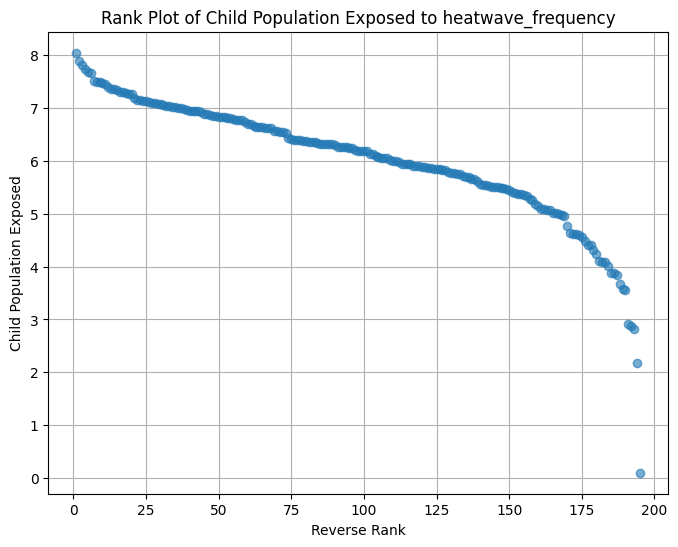

processed : heatwave_duration min: 0.1 max: 7.969618072781161
heatwave_duration: Log Transformation and Scaling - skew=-1.195, kurtosis=0.067
IQR processed : heatwave_duration min: 1.5140569052181596 max: 9.924203354750242


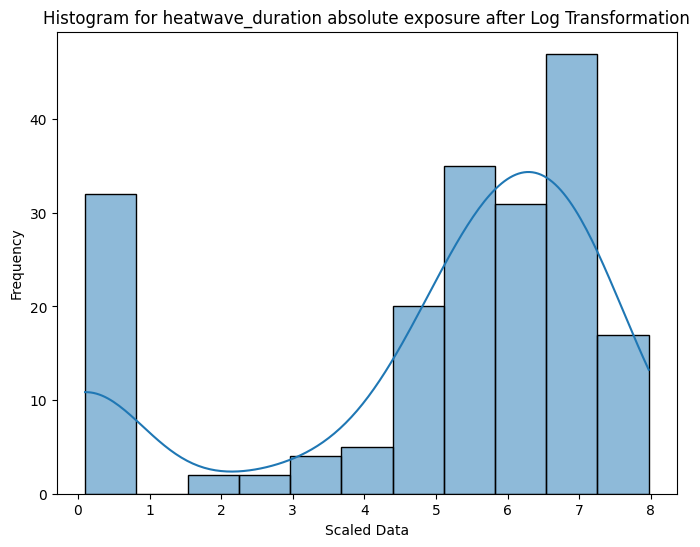

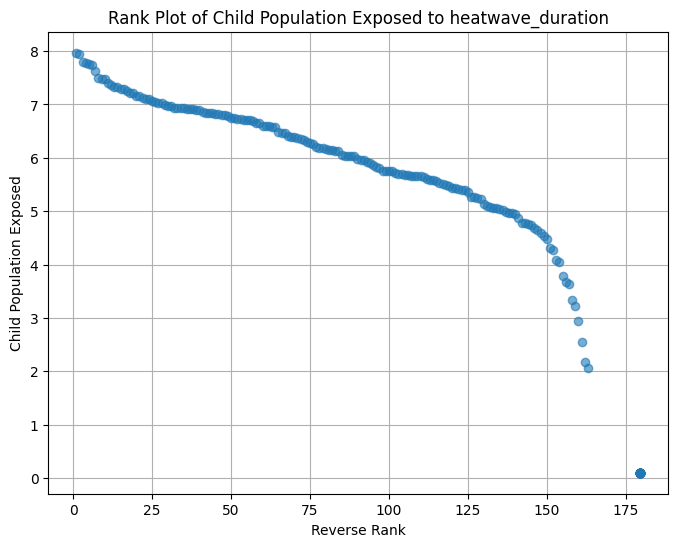

processed : heatwave_severity min: 0.1 max: 7.930884497024643
heatwave_severity: Log Transformation and Scaling - skew=-0.066, kurtosis=-1.698
IQR processed : heatwave_severity min: -8.46598414319278 max: 14.37664023865463


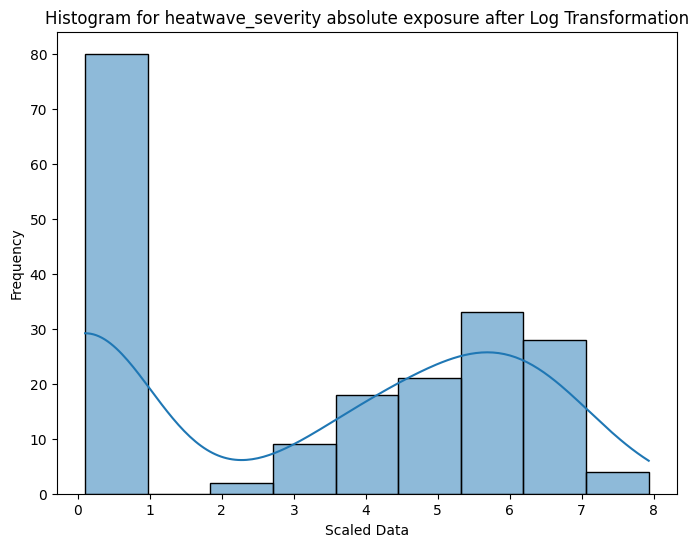

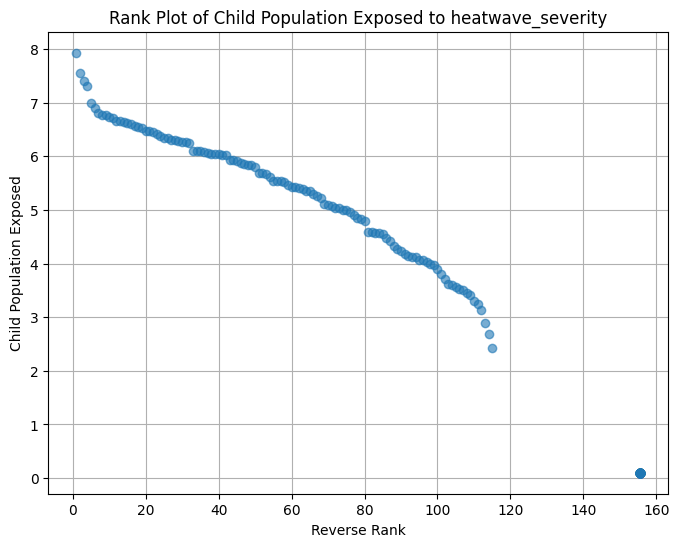

processed : extreme_heat min: 0.1 max: 8.598808536509011
extreme_heat: Log Transformation and Scaling - skew=-0.171, kurtosis=-1.779
IQR processed : extreme_heat min: -9.362860964676578 max: 15.871434941127628


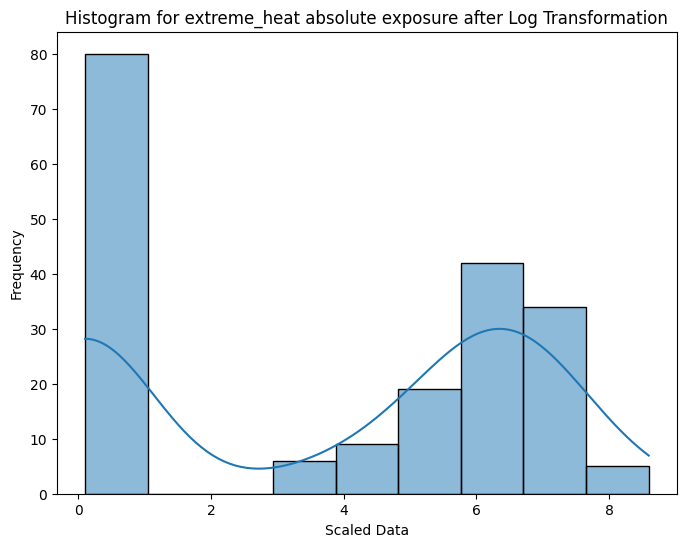

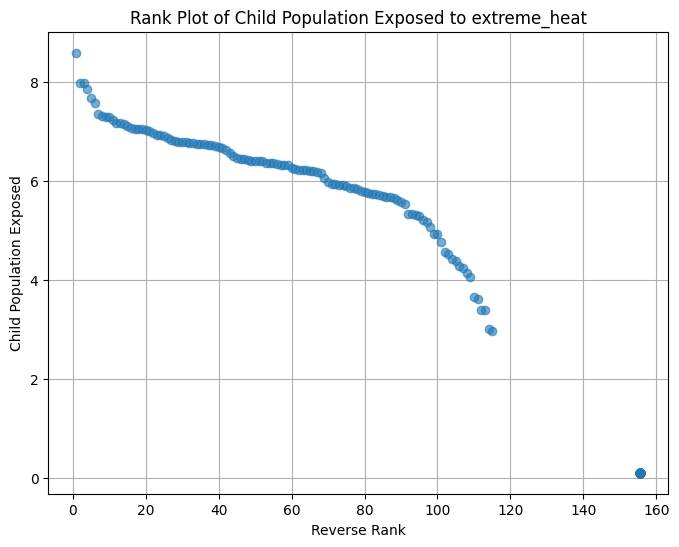

processed : fire_FRP min: 0.1 max: 6.877689694575995
fire_FRP: Log Transformation and Scaling - skew=-1.257, kurtosis=0.413
IQR processed : fire_FRP min: 1.2203981110373707 max: 8.25601952944527


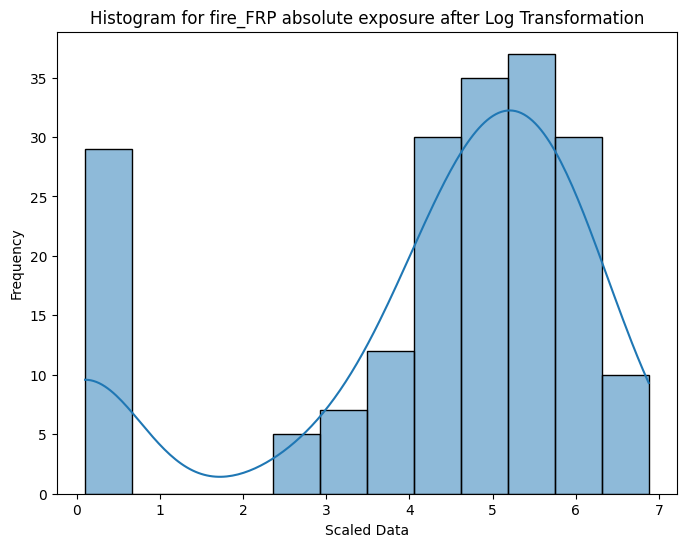

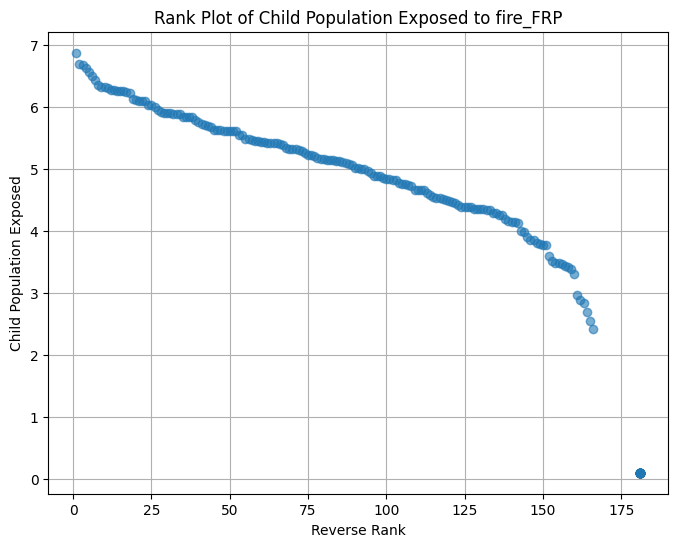

processed : fire_frequency min: 0.1 max: 7.351129607420607
fire_frequency: Log Transformation and Scaling - skew=-0.881, kurtosis=-0.191
IQR processed : fire_frequency min: -0.34835494325281013 max: 9.2358119968646


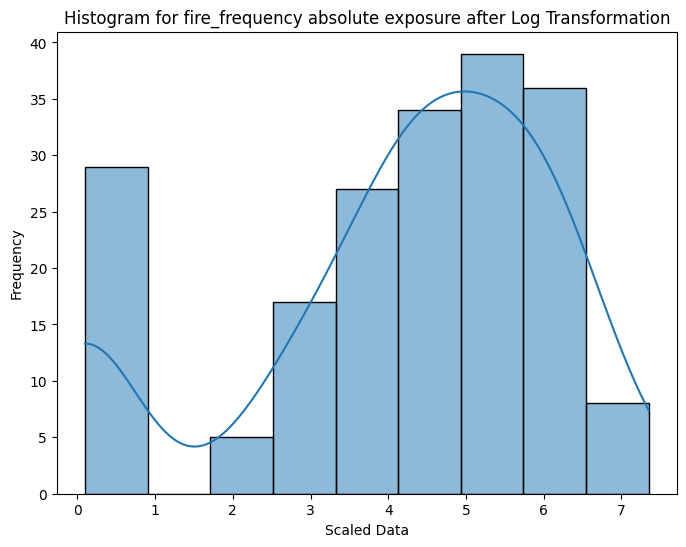

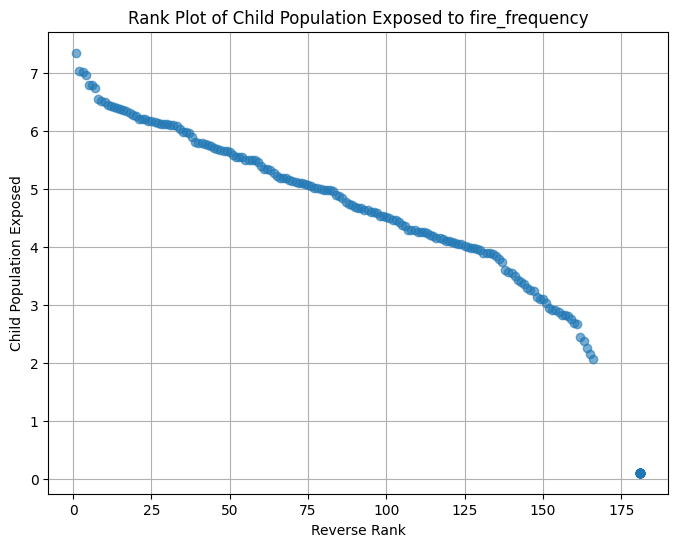

processed : sand_dust min: 0.1 max: 7.205487919815677
sand_dust: Log Transformation and Scaling - skew=-0.227, kurtosis=-1.214
IQR processed : sand_dust min: -7.519894944787303 max: 12.799824907978838


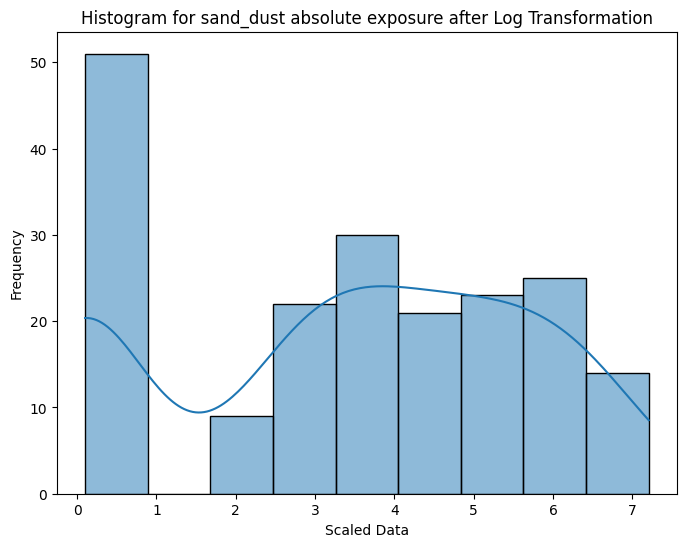

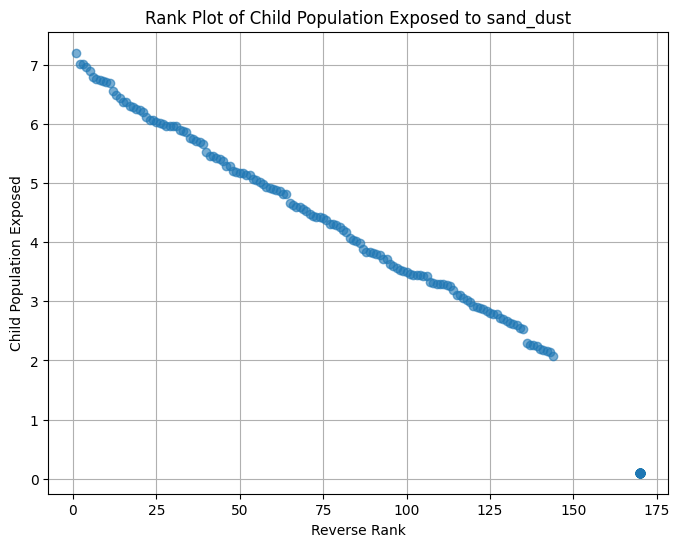

processed : air_pollution min: 2.2293410432515928 max: 8.43307628954952
air_pollution: Log Transformation and Scaling - skew=-0.993, kurtosis=1.116
IQR processed : air_pollution min: 3.7678103182818368 max: 8.919140022509675


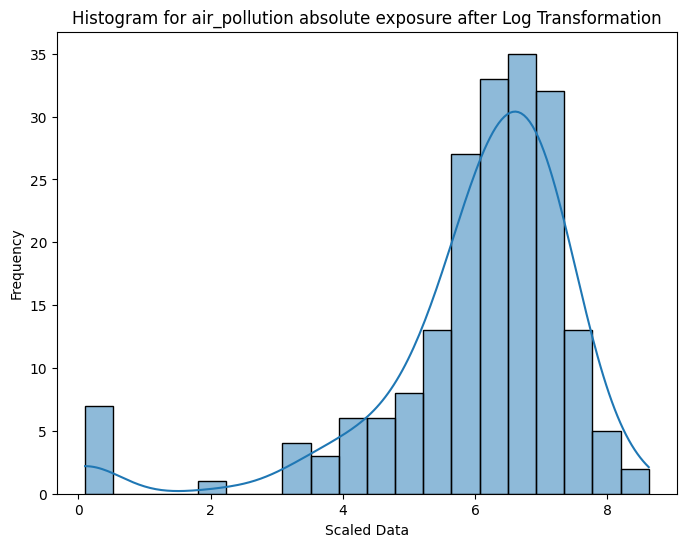

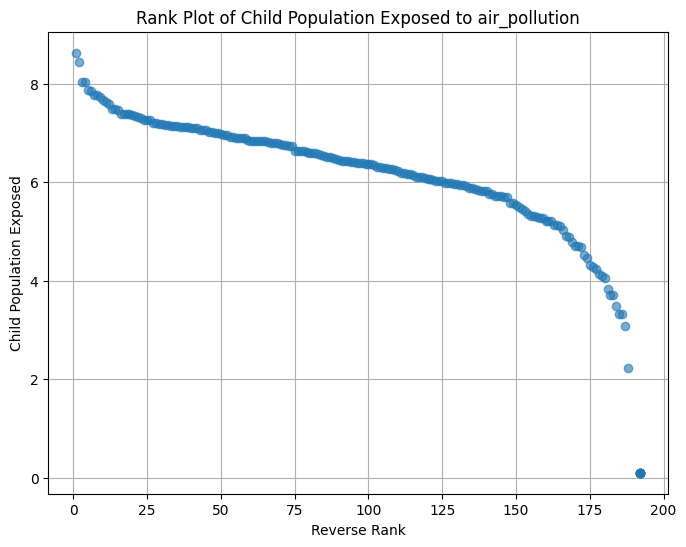

processed : vectorborne_malariapv min: 0.1 max: 8.523170629252881
vectorborne_malariapv: Log Transformation and Scaling - skew=1.318, kurtosis=0.036
IQR processed : vectorborne_malariapv min: -4.125478154545263 max: 7.142463590908771


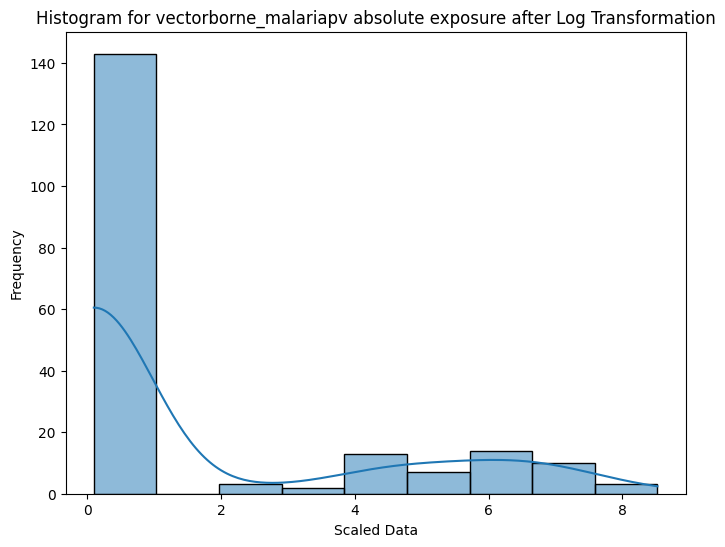

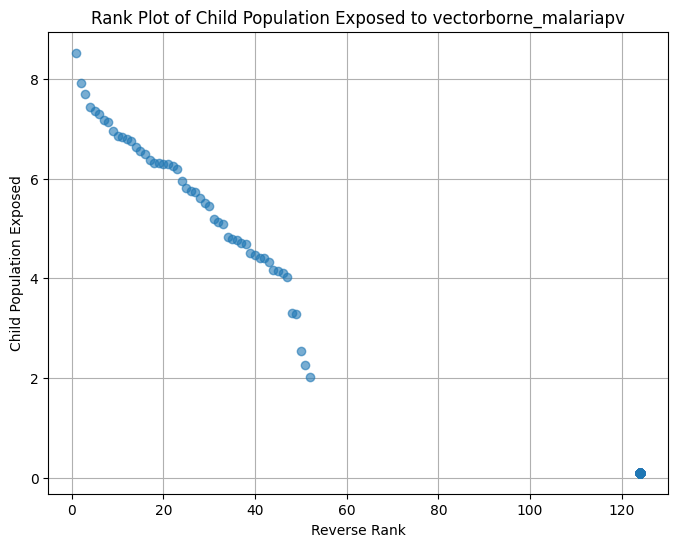

processed : vectorborne_malariapf min: 0.1 max: 8.043459099006963
vectorborne_malariapf: Log Transformation and Scaling - skew=0.481, kurtosis=-1.588
IQR processed : vectorborne_malariapf min: -8.700440171582214 max: 14.767400285970355


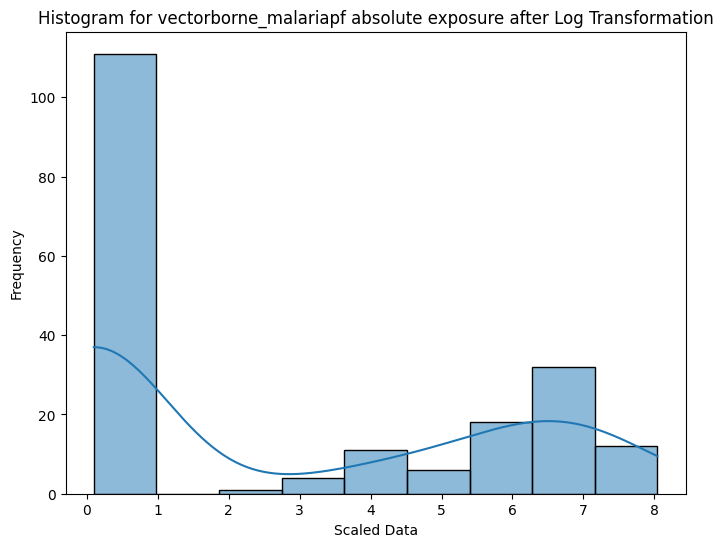

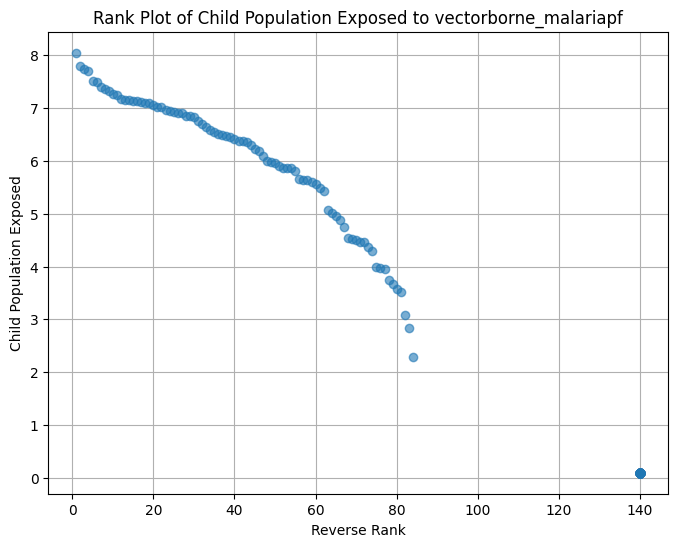

In [ ]:

# Folder containing the CSV files
path = f'{data_dir}/p1_exposure'
all_files = glob.glob(path + "/*.csv")

for file in all_files:
    # Exclude the specified file
    df = pd.read_csv(file, index_col=None, header=0)
    df = df.rename(columns={'exposed': 'child_population_exposed'})
    filename_only = file.split('/')[-1]
    hazard_name = '_'.join(filename_only.split('_')[:2])

    if iso3_name not in df.columns or 'child_population_exposed' not in df.columns:
        continue  # Skip files missing required columns

    df = df[[iso3_name, 'child_population_exposed']].dropna()

    # Apply iterative trimming
    # before data trimming, log10 is applied to values higher than 100 otherwise asign 0.1
    df['child_population_exposed'] = df['child_population_exposed'].dropna().values  # Ensure no NaNs
    with np.errstate(divide='ignore'):
      df['child_population_exposed'] = np.where(
          df['child_population_exposed'] > 100,
          np.log10(df['child_population_exposed']),
          0.1
      )
    trimmed_values, min_trimmed, max_trimmed = trim_outliers_iteratively(df['child_population_exposed'])
    iqr_trimmed_values, iqr_lower_bound, iqr_upper_bound = boxplot_outlier_detection(df['child_population_exposed'])

    print(f"processed : {hazard_name} min: {min_trimmed} max: {max_trimmed}" )
    current_skew = skew(trimmed_values)
    current_kurtosis = kurtosis(trimmed_values)
    print(f"{hazard_name}: Log Transformation and Scaling - skew={current_skew:.3f}, kurtosis={current_kurtosis:.3f}")
    print(f"IQR processed : {hazard_name} min: {iqr_lower_bound} max: {iqr_upper_bound}" )

    # Plot histogram and normality check
    plt.figure(figsize=(8, 6))
    sns.histplot(df['child_population_exposed'], kde=True)
    plt.title(f"Histogram for {hazard_name} absolute exposure after Log Transformation")
    plt.xlabel("Scaled Data")
    plt.ylabel("Frequency")
    plt.show()

    # Compute ranks in reverse order
    df['rank_reverse'] = df['child_population_exposed'].rank(method='average', ascending=False)
    plt.figure(figsize=(8, 6))
    plt.plot(df['rank_reverse'], df['child_population_exposed'], marker='o', linestyle='', alpha=0.6)
    plt.xlabel("Reverse Rank")
    plt.ylabel("Child Population Exposed")
    plt.title(f"Rank Plot of Child Population Exposed to {hazard_name}")
    plt.grid(True)
    plt.show()



0.0
75.94668833308751
Processed: river_flood | Min: 0.2842975797351262 | Max: 33.60213636101222
river_flood: Log Transformation - skew=1.713, kurtosis=3.199
IQR processed : river_flood min: -777208.6800104304 max: 1323838.7237201384


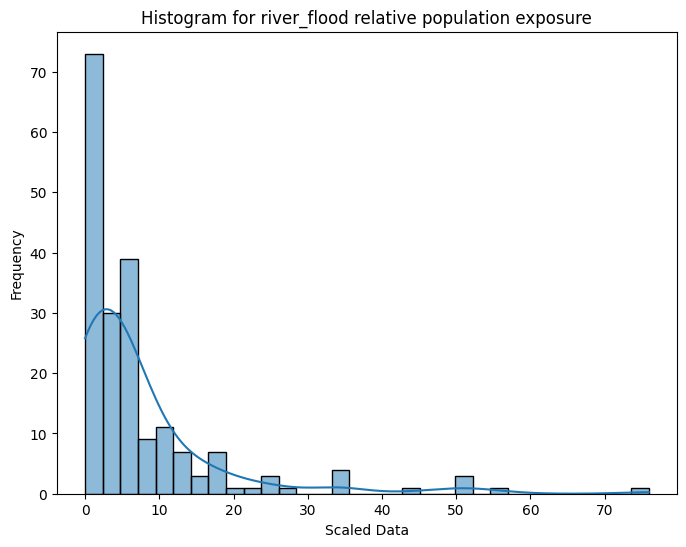

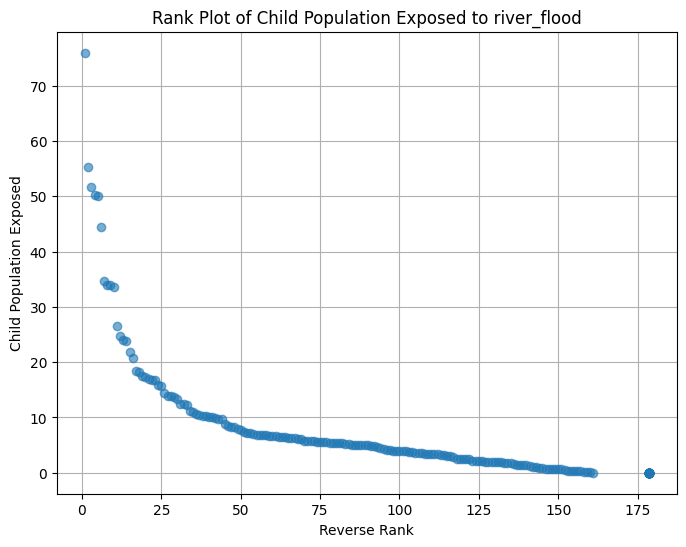

0.0
47.32729793448633
Processed: coastal_flood | Min: 0.027847175400661884 | Max: 3.590093100917642
coastal_flood: Log Transformation - skew=1.899, kurtosis=3.221
IQR processed : coastal_flood min: -25528.553302577537 max: 42547.58883762923


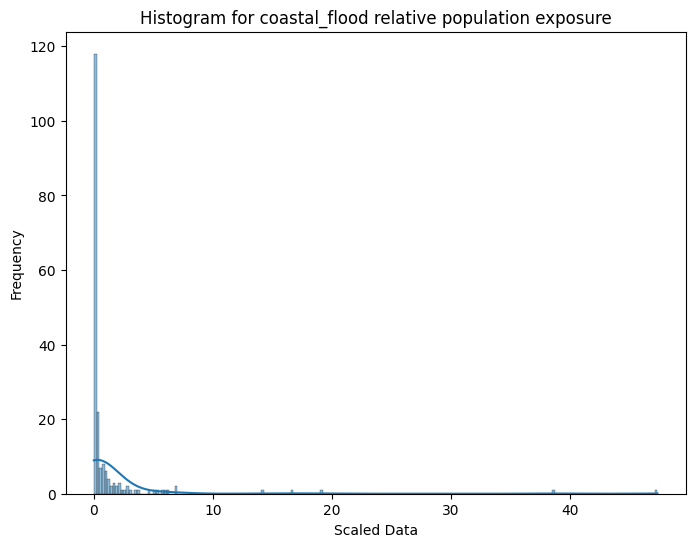

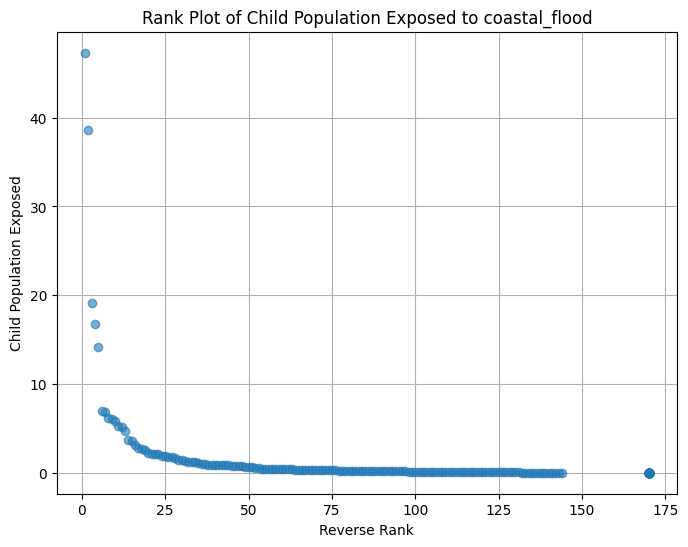

0.0
100.00000000000003
Processed: tropical_storm | Min: 0.0 | Max: 100.00000000000003
tropical_storm: Log Transformation - skew=1.071, kurtosis=-0.694
IQR processed : tropical_storm min: -528883.5348527493 max: 881472.5580879155


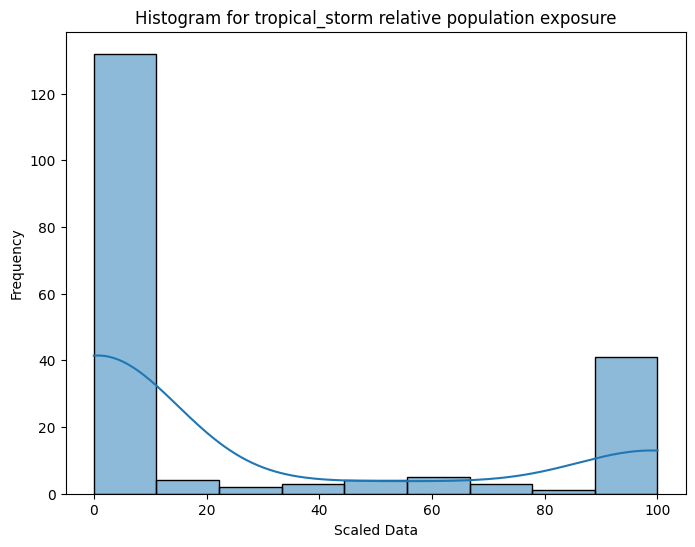

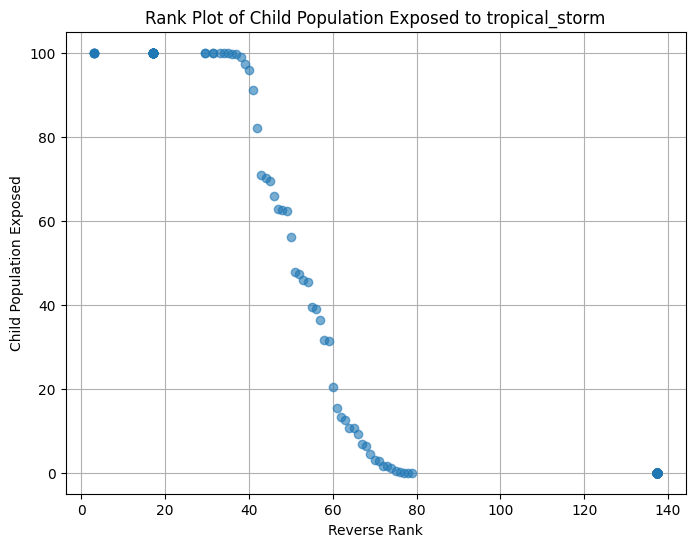

0.0
100.0
Processed: agricultural_drought | Min: 0.0 | Max: 100.0
agricultural_drought: Log Transformation - skew=0.122, kurtosis=-1.182
IQR processed : agricultural_drought min: -6498248.803723693 max: 11065085.52045314


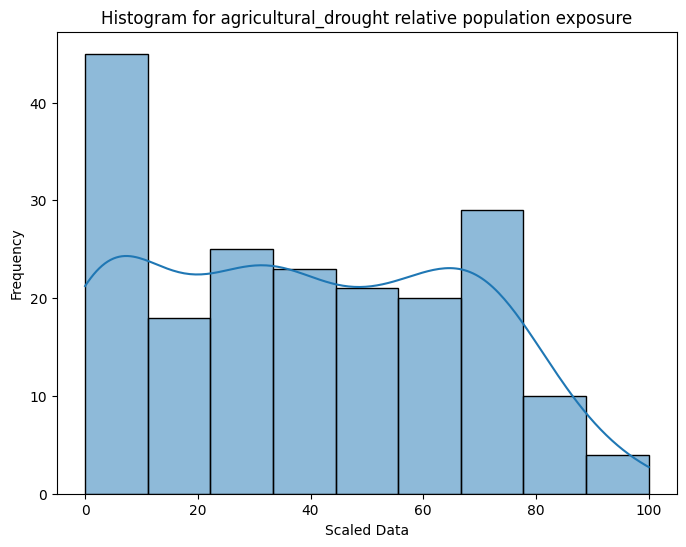

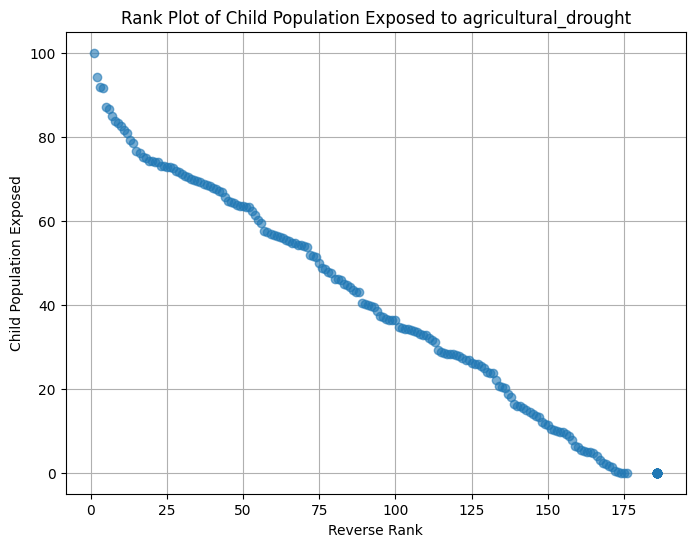

0.0
100.00000000000003
Processed: drought_spei | Min: 0.0 | Max: 100.00000000000003
drought_spei: Log Transformation - skew=-0.579, kurtosis=-1.213
IQR processed : drought_spei min: -9322441.404992018 max: 15971471.135115173


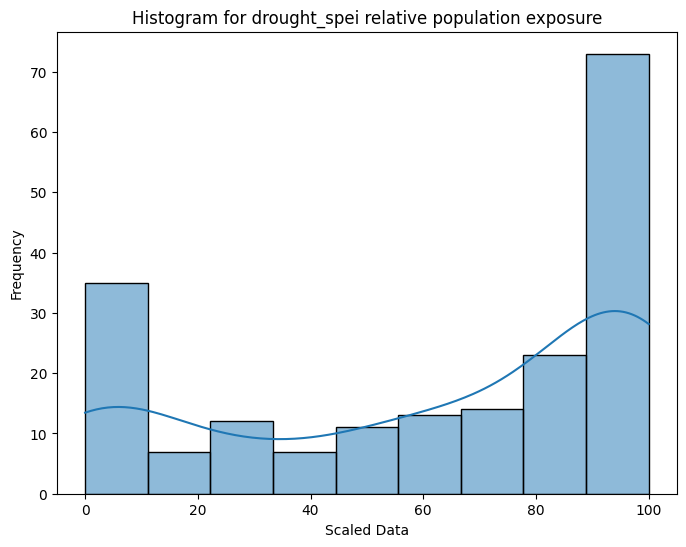

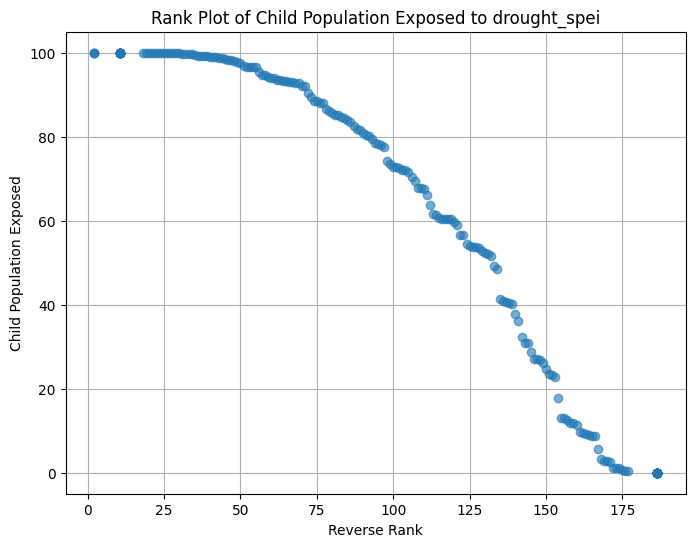

0.0
100.0
Processed: drought_spi | Min: 0.0 | Max: 100.0
drought_spi: Log Transformation - skew=0.192, kurtosis=-1.419
IQR processed : drought_spi min: -6610678.485039399 max: 11082757.411931261


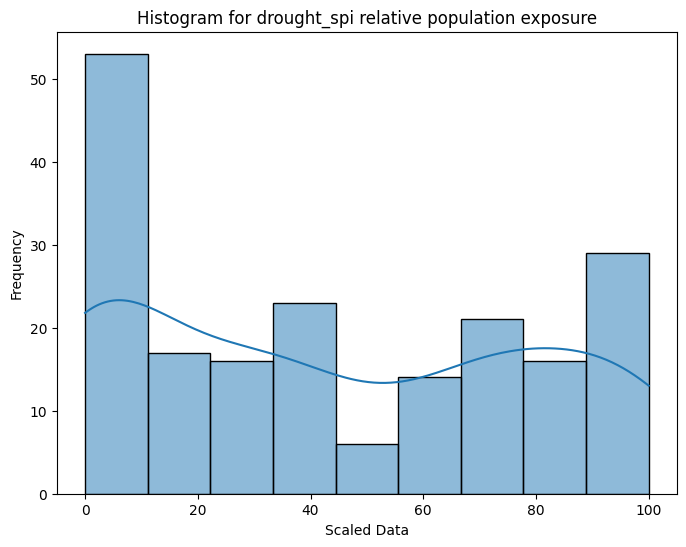

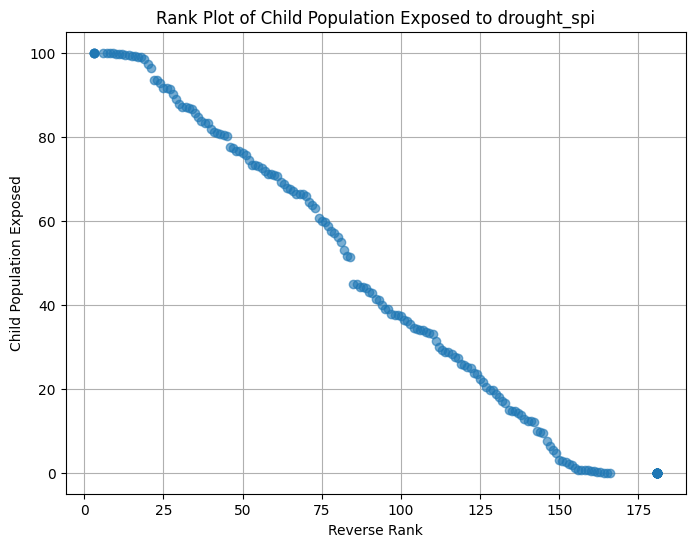

0.05648794966861656
100.0
Processed: heatwave_frequency | Min: 0.05648794966861656 | Max: 100.0
heatwave_frequency: Log Transformation - skew=-1.168, kurtosis=0.334
IQR processed : heatwave_frequency min: -9582066.754389793 max: 16816544.66656084


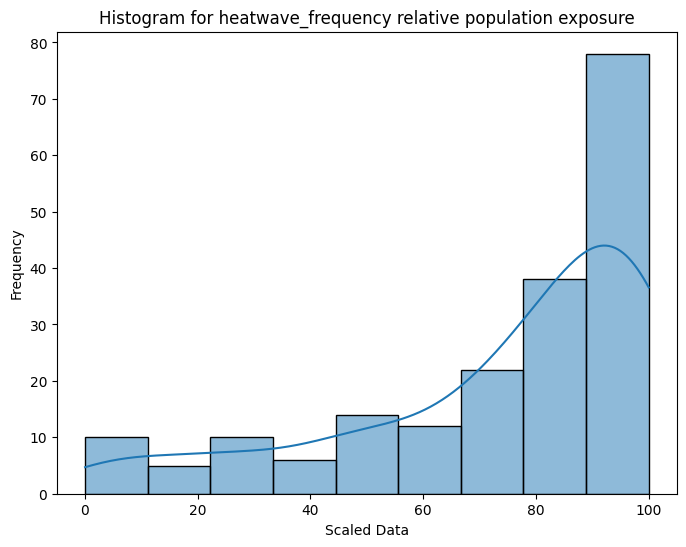

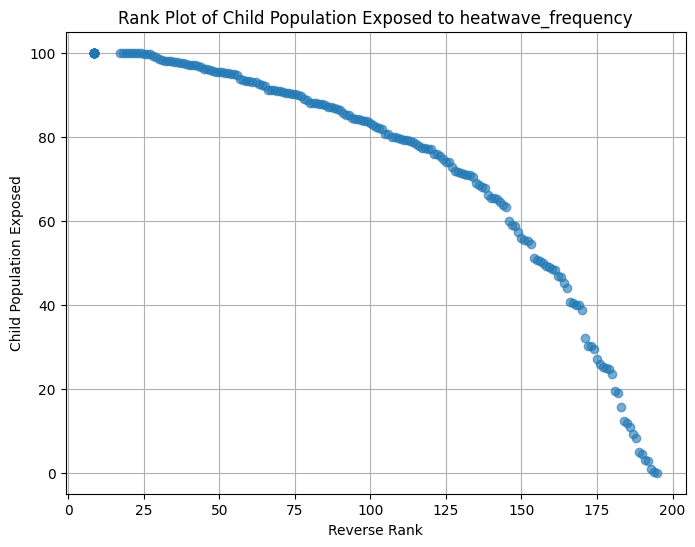

0.0
100.0
Processed: heatwave_duration | Min: 0.0 | Max: 100.0
heatwave_duration: Log Transformation - skew=0.110, kurtosis=-1.543
IQR processed : heatwave_duration min: -8733448.29602667 max: 14680061.33878346


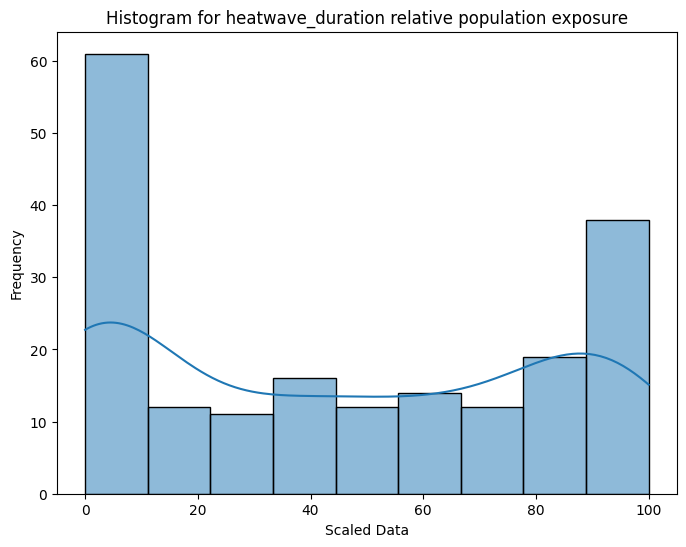

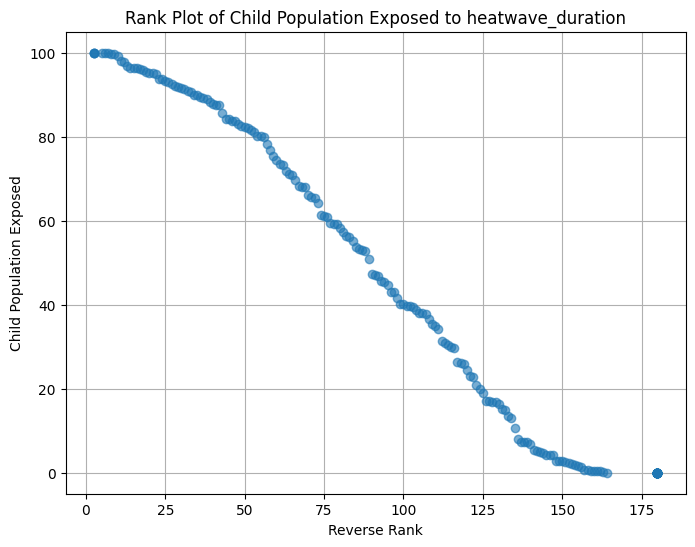

0.0
87.70140329296355
Processed: heatwave_severity | Min: 0.0 | Max: 87.70140329296355
heatwave_severity: Log Transformation - skew=1.804, kurtosis=2.233
IQR processed : heatwave_severity min: -970802.3026456553 max: 1618003.837742759


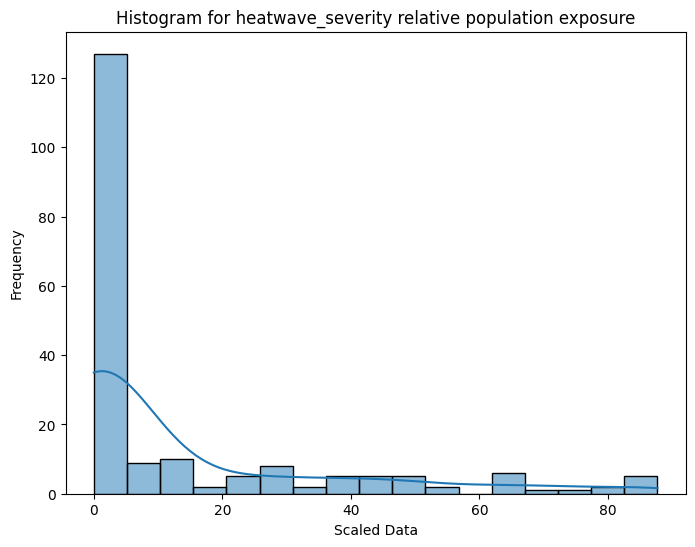

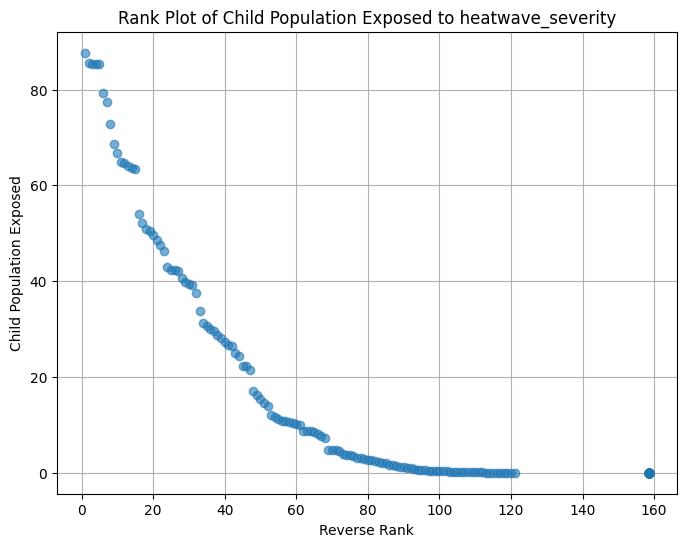

0.0
100.00000000000003
Processed: extreme_heat | Min: 0.0 | Max: 100.00000000000003
extreme_heat: Log Transformation - skew=1.041, kurtosis=-0.457
IQR processed : extreme_heat min: -3842982.744658298 max: 6404971.241097163


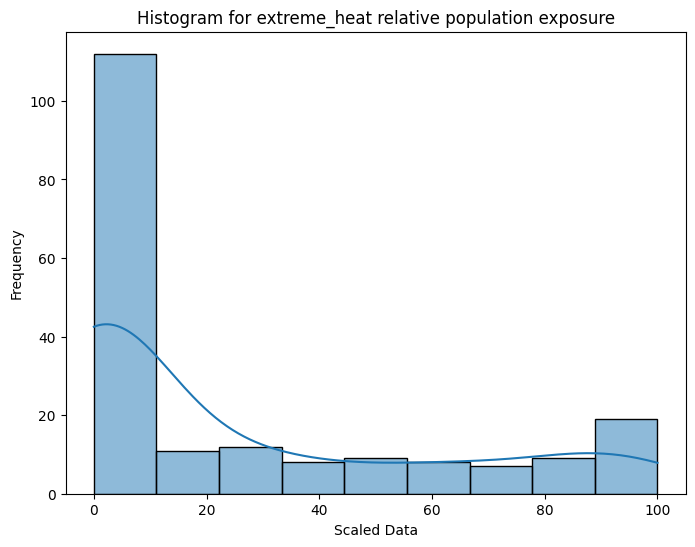

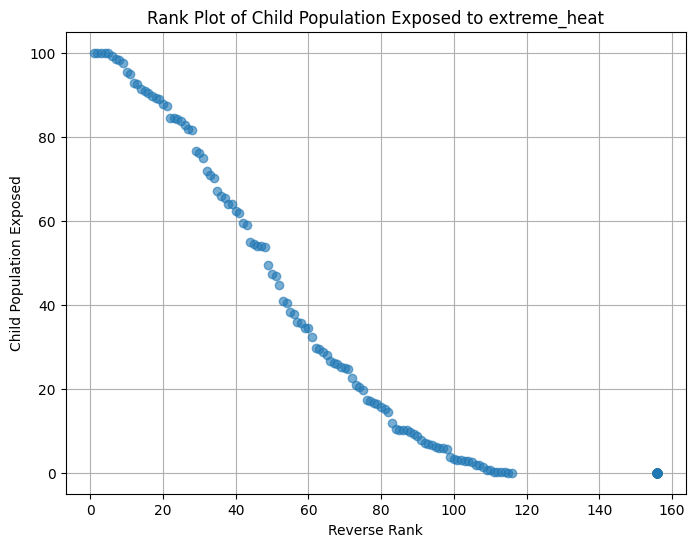

0.0
49.54498100687577
Processed: fire_FRP | Min: 0.17420590897752575 | Max: 22.03191784243057
fire_FRP: Log Transformation - skew=1.748, kurtosis=3.448
IQR processed : fire_FRP min: -603888.0740525877 max: 1025743.2791413456


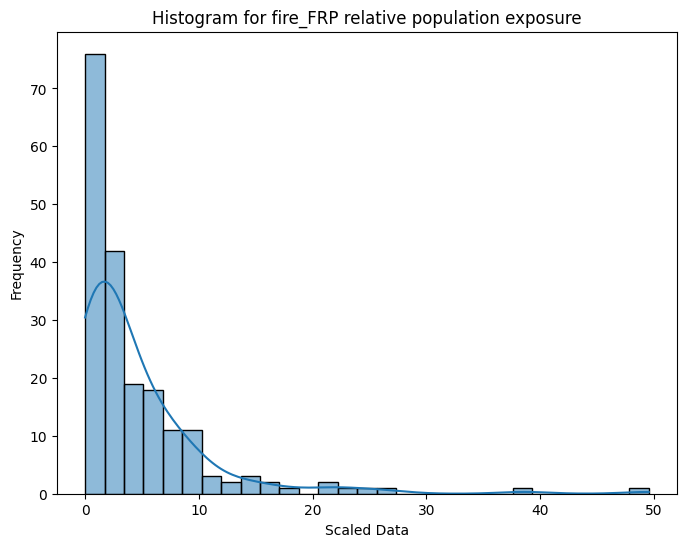

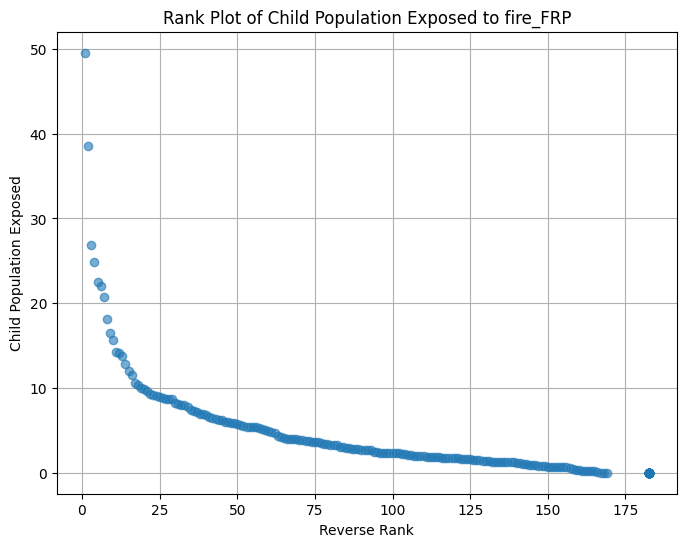

0.0
72.0188117789529
Processed: fire_frequency | Min: 0.07767391990045373 | Max: 27.638150013434853
fire_frequency: Log Transformation - skew=1.820, kurtosis=3.352
IQR processed : fire_frequency min: -653179.3742031257 max: 1093327.887150467


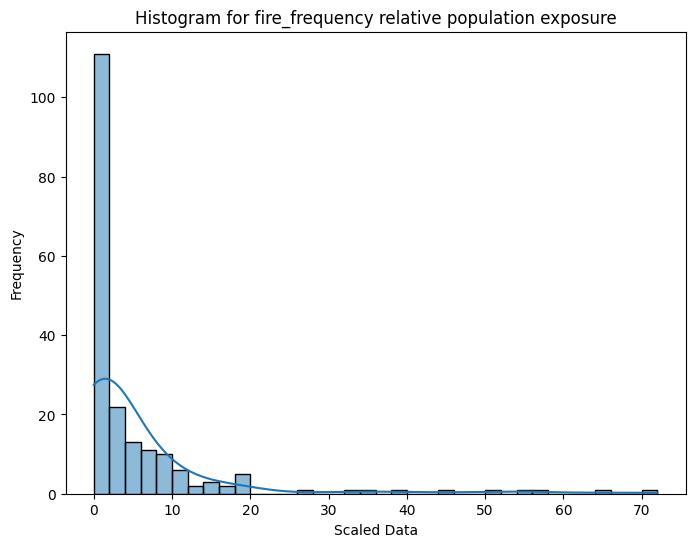

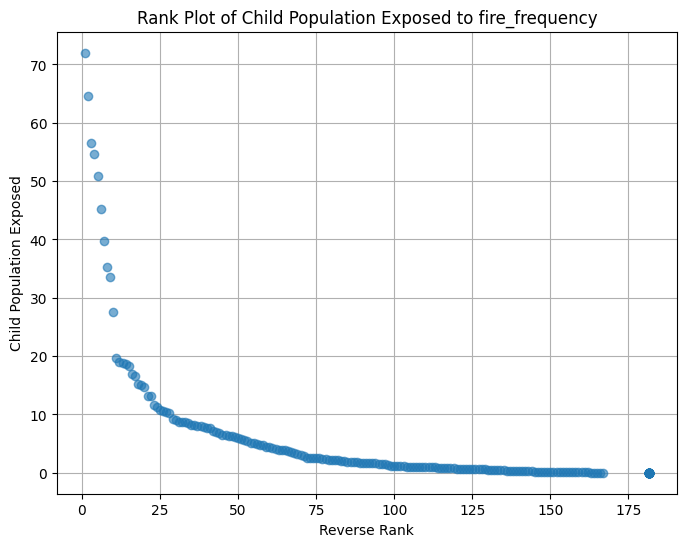

0.0
79.3973744474806
Processed: sand_dust | Min: 0.011091421985076714 | Max: 12.451761179508859
sand_dust: Log Transformation - skew=1.999, kurtosis=3.233
IQR processed : sand_dust min: -226775.5603321096 max: 378209.4473682124


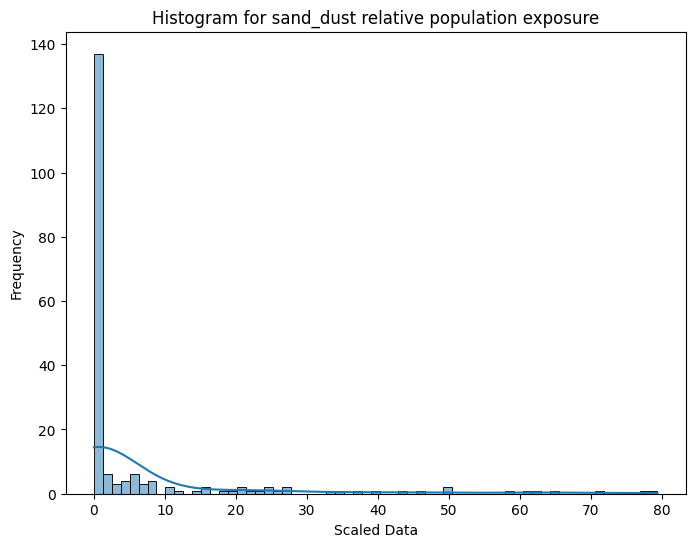

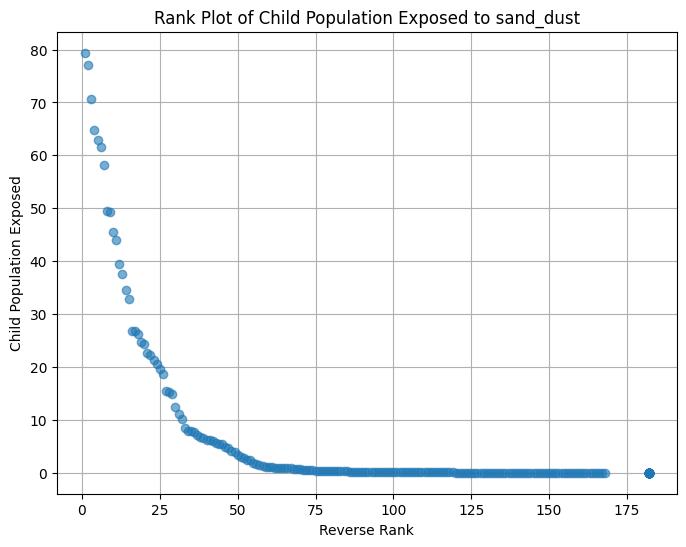

0.0
100.0
Processed: air_pollution | Min: 59.11040142129289 | Max: 99.96489433816448
air_pollution: Log Transformation - skew=-1.981, kurtosis=3.383
IQR processed : air_pollution min: -13320540.2738188 max: 23536194.73834304


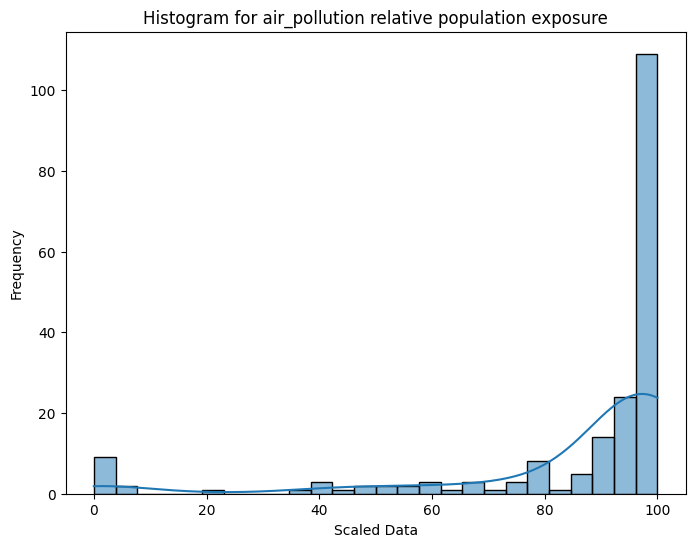

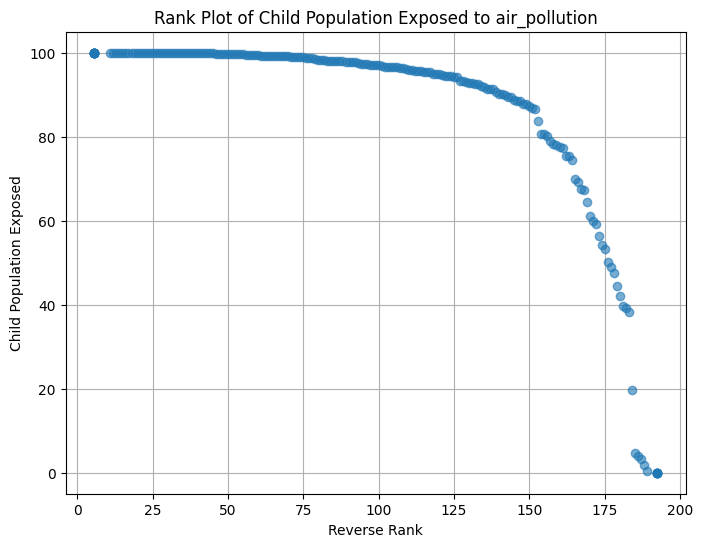

0.0
99.99443007103316
Processed: vectorborne_malariapv | Min: 0.00028292404050142214 | Max: 99.88643805062216
vectorborne_malariapv: Log Transformation - skew=0.604, kurtosis=-1.345
IQR processed : vectorborne_malariapv min: -1730.7851775296579 max: 2884.64196254943


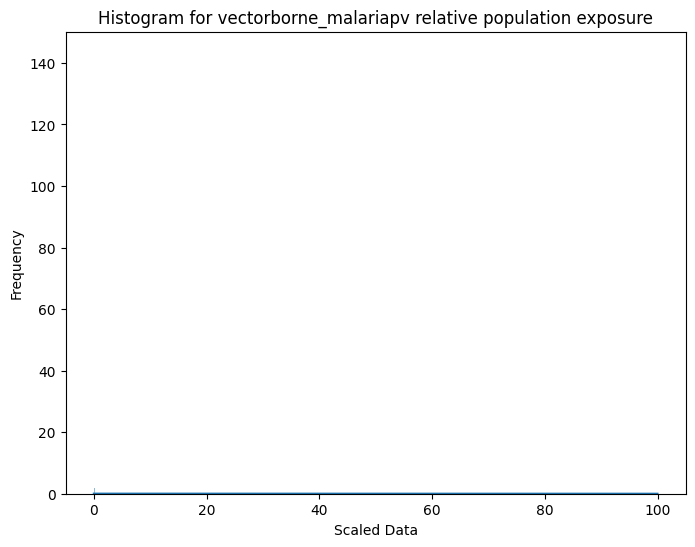

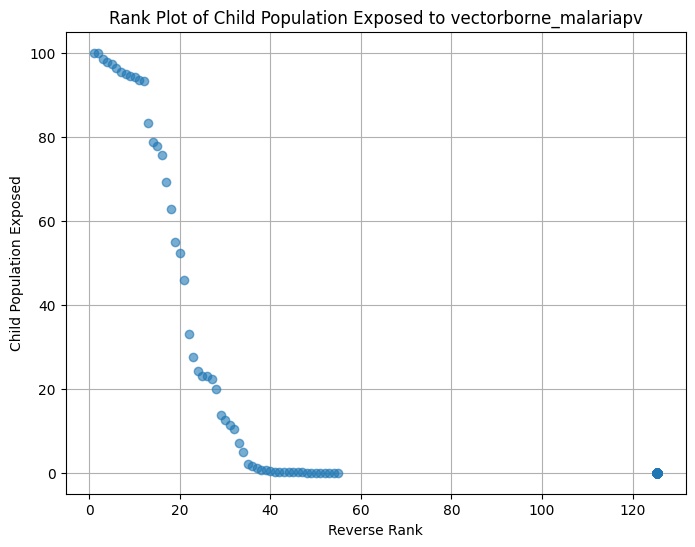

0.0
100.0
Processed: vectorborne_malariapf | Min: 0.0 | Max: 100.0
vectorborne_malariapf: Log Transformation - skew=1.167, kurtosis=-0.526
IQR processed : vectorborne_malariapf min: -1390396.436412999 max: 2317327.3940216647


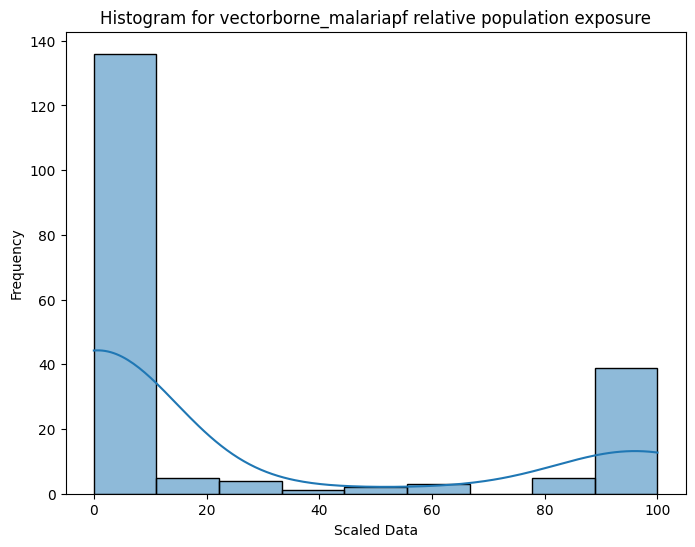

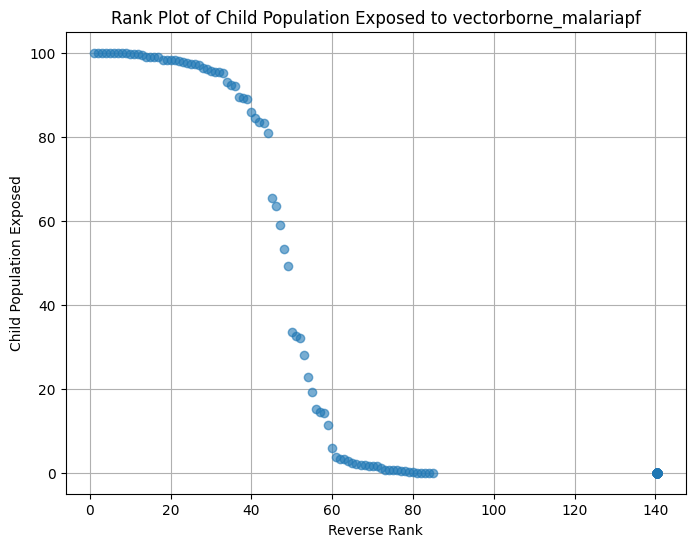

In [ ]:

# Process each hazard file
for file in all_files:
    # Exclude the total population file
    df = pd.read_csv(file, index_col=None, header=0)
    df = df.rename(columns={'exposed': 'child_population_exposed'})
    df = df.rename(columns={'child_total': 'child_population_total'})
    filename_only = file.split('/')[-1]
    hazard_name = '_'.join(filename_only.split('_')[:2])

    if iso3_name not in df.columns or 'child_population_exposed' not in df.columns:
        continue  # Skip files missing required columns

    df = df[[iso3_name, 'child_population_exposed','child_population_total']].dropna()
    df['relative_population_exposure'] = np.where(
        (df['child_population_total'] > 0) & (~df['child_population_total'].isna()),
        (df['child_population_exposed'] / df['child_population_total']) * 100,
        np.nan  # Assign NaN instead of inf
    )

    print( df['relative_population_exposure'].min())
    print( df['relative_population_exposure'].max())
    # Apply iterative trimming
    # Trim outliers
    trimmed_values, min_trimmed, max_trimmed = trim_outliers_iteratively(df['relative_population_exposure'])
    iqr_trimmed_values, iqr_lower_bound, iqr_upper_bound = boxplot_outlier_detection(df['child_population_exposed'])
    # Check if there are enough values to calculate skewness and kurtosis
    if len(trimmed_values) > 2:
        current_skew = skew(trimmed_values)
        current_kurtosis = kurtosis(trimmed_values)
    else:
        current_skew, current_kurtosis = np.nan, np.nan

    print(f"Processed: {hazard_name} | Min: {min_trimmed} | Max: {max_trimmed}" )
    print(f"{hazard_name}: Log Transformation - skew={current_skew:.3f}, kurtosis={current_kurtosis:.3f}")
    print(f"IQR processed : {hazard_name} min: {iqr_lower_bound} max: {iqr_upper_bound}" )

    # Plot histogram and normality check
    plt.figure(figsize=(8, 6))
    sns.histplot(df['relative_population_exposure'], kde=True)
    plt.title(f"Histogram for {hazard_name} relative population exposure")
    plt.xlabel("Scaled Data")
    plt.ylabel("Frequency")
    plt.show()


    # Compute ranks in reverse order
    df['rank_reverse'] = df['relative_population_exposure'].rank(method='average', ascending=False)
    plt.figure(figsize=(8, 6))
    plt.plot(df['rank_reverse'], df['relative_population_exposure'], marker='o', linestyle='', alpha=0.6)
    plt.xlabel("Reverse Rank")
    plt.ylabel("Child Population Exposed")
    plt.title(f"Rank Plot of Child Population Exposed to {hazard_name}")
    plt.grid(True)
    plt.show()




In [ ]:
import os
import numpy as np
import pandas as pd
import glob
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from scipy.stats import skew, kurtosis

# Define file paths
exposure_path = f'{data_dir}/p1_exposure'

# Get all CSV files for exposure
exposure_files = glob.glob(os.path.join(exposure_path, "*.csv"))

# Initialize empty list for processed data
exposure_data_list = []

### **Process Each File in One Loop**
for file in exposure_files:

    df = pd.read_csv(file)  # Read full file to check available columns
    df = df.rename(columns={'exposed': 'child_population_exposed'})
    df = df.rename(columns={'child_total': 'child_population_total'})
    df = df.merge(adm0_df, left_on='ucode', right_on='ucode')

    df =  df[df['type'] == 'State'] #filter out areas other than 'State'
    filename_only = os.path.basename(file)
    hazard_name = '_'.join(filename_only.split('_')[:2])  # Extract hazard name

    # Ensure required columns exist
    required_cols = {iso3_name, adm_name, 'child_population_exposed', 'child_population_total'}
    if not required_cols.issubset(df.columns):
        print(f"Skipping {file}: Missing columns {required_cols - set(df.columns)}")
        continue  # Skip if required columns are missing

    df.dropna(subset=['child_population_exposed'], inplace=True)

    ### **Step 1: Absolute Exposure Processing**
    # Log transform with clipping for values >100, otherwise assign 0.1
    df['absolute_exposure'] = np.where(df['child_population_exposed'] > 100,
                                       np.log10(df['child_population_exposed'].clip(lower=1)),  # Clip to avoid log10(0)
                                       0.1)
    #open min_max data file and use them to normalize the values
    df_min_max = pd.read_csv(f'{data_dir}/CCRI_results_misc/p1_min_max.csv')
    min_trimmed = df_min_max.loc[(df_min_max['filename'] == hazard_name) & (df_min_max['type'] == 'abs'),'min'].values[0]
    max_trimmed = df_min_max.loc[(df_min_max['filename'] == hazard_name) & (df_min_max['type'] == 'abs'),'max'].values[0]

    # clip to min max
    df['absolute_exposure'] = np.clip(df['absolute_exposure'], min_trimmed, max_trimmed)
    scaler = MinMaxScaler(feature_range=(1, 10))  # scale to 1–10
    df['absolute_value_normalized'] = scaler.fit_transform(df[['absolute_exposure']]).flatten()

    ### **Step 2: Relative Exposure Processing**

    # Compute relative exposure (%)
    df['relative_exposure'] = np.where(
        (df['child_population_total'] > 0) & (~df['child_population_total'].isna()),
        (df['child_population_exposed'] / df['child_population_total']) * 100,
        0
    )

    # #get min max values for relative exposures
    min_trimmed = df_min_max.loc[(df_min_max['filename'] == hazard_name) & (df_min_max['type'] == 'rel'),'min'].values[0]
    max_trimmed = df_min_max.loc[(df_min_max['filename'] == hazard_name) & (df_min_max['type'] == 'rel'),'max'].values[0]

    # # Normalize relative exposure
    df['relative_exposure'] = np.clip(df['relative_exposure'], min_trimmed, max_trimmed)
    df['relative_value_normalized'] = scaler.fit_transform(df[['relative_exposure']]).flatten()

    #If absolute value is zero, relative is also zero
    df.loc[df['absolute_value_normalized'] == 0, 'relative_value_normalized'] = 0
    df.loc[df['relative_value_normalized'] == 0, 'absolute_value_normalized'] = 0

    # Rename columns for final merging
    df.rename(columns={
        'absolute_value_normalized': hazard_name + '_absolute',
        'relative_value_normalized': hazard_name + '_relative'
    }, inplace=True)

    # Append processed data to list
    exposure_data_list.append(df[[iso3_name, adm_name,
                                  hazard_name + '_absolute',
                                  hazard_name + '_relative']])

### **Final Merge Step**
# Concatenate all processed DataFrames
#merged_exposure_df = pd.concat(exposure_data_list, axis=1).drop_duplicates(subset=[iso3_name, adm_name])
merged_exposure_df = pd.concat(exposure_data_list, axis=1)

# Ensure no duplicate columns before merging
merged_exposure_df = merged_exposure_df.loc[:, ~merged_exposure_df.columns.duplicated()]
merged_exposure_df = merged_exposure_df.rename(columns={iso3_name: "iso3"})

# Save merged exposure data
output_path = f"{data_dir}/CCRI_results_misc/Merged_Exposure_Data.csv"
merged_exposure_df.to_csv(output_path, index=False)
print(f"Merged exposure data saved to {output_path}")


Merged exposure data saved to /content/drive/MyDrive/CCRI/ccri_repo/data/CCRI_results_misc/Merged_Exposure_Data.csv
